group by year, plot trend lines (rolling average and CI later), export figures 

In [3]:
# load results 

import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.read_csv("/Users/mariaworkman/VSCode25/fashion-neutrality/data/results/metrics_full_run.csv")

# keep only valid rows
metrics_df = metrics_df[metrics_df["ok"] == True]

In [4]:
# aggregate by year 

yearly = (
    metrics_df
    .groupby("year")
    .agg(
        mean_chroma=("mean_chroma", "mean"),
        neutral_share=("neutral_share", "mean"),
        count=("mean_chroma", "size")
    )
    .reset_index()
    .sort_values("year")
)

yearly.head()


,year,mean_chroma,neutral_share,count
0,2010,12.373498,0.797284,100
1,2011,14.389573,0.765280,100
2,2012,14.472742,0.750420,100
3,2013,12.378383,0.801602,100
4,2014,12.042843,0.827149,100


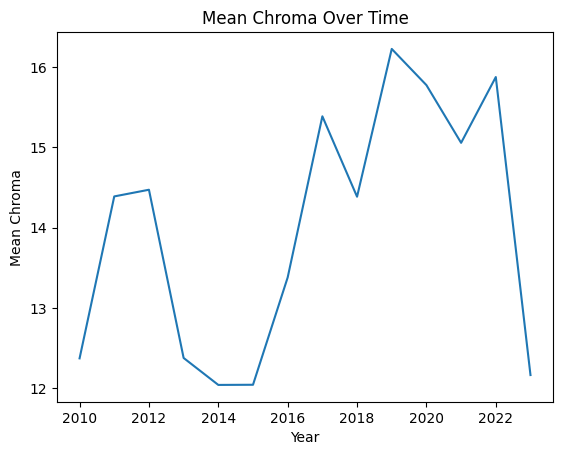

In [5]:
# plot mean chroma over years 

plt.figure()
plt.plot(yearly["year"], yearly["mean_chroma"])
plt.xlabel("Year")
plt.ylabel("Mean Chroma")
plt.title("Mean Chroma Over Time")
plt.show()


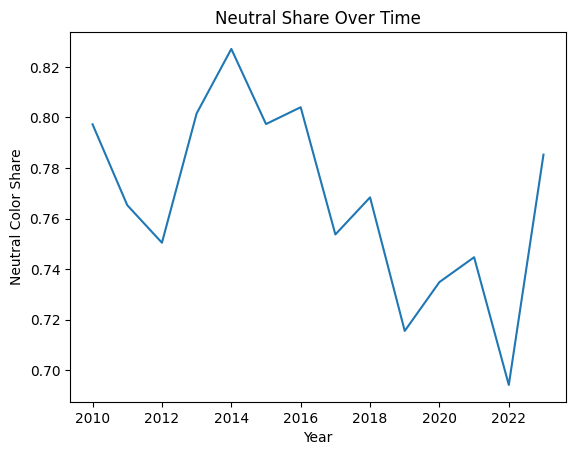

In [6]:
# plot neutral share over years (could be pretty messy, need to adjust cutoff for neutrality)

plt.figure()
plt.plot(yearly["year"], yearly["neutral_share"])
plt.xlabel("Year")
plt.ylabel("Neutral Color Share")
plt.title("Neutral Share Over Time")
plt.show()


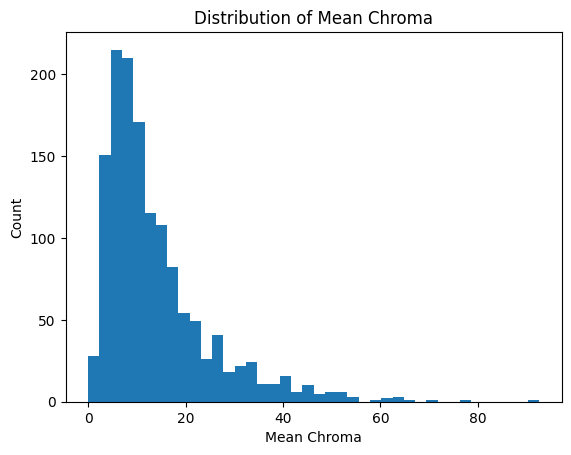

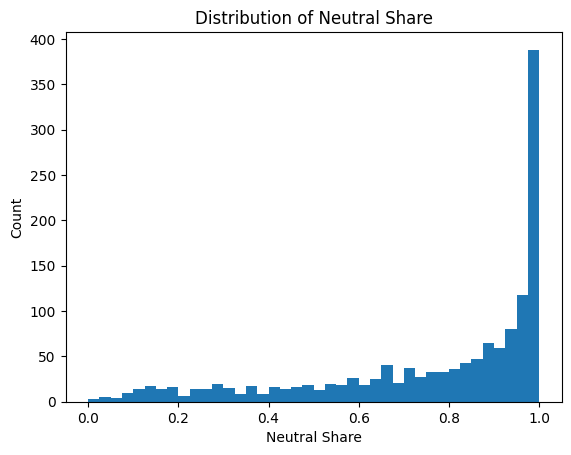

In [7]:
# distribution checks 

plt.figure()
plt.hist(metrics_df["mean_chroma"], bins=40)
plt.xlabel("Mean Chroma")
plt.ylabel("Count")
plt.title("Distribution of Mean Chroma")
plt.show()

plt.figure()
plt.hist(metrics_df["neutral_share"], bins=40)
plt.xlabel("Neutral Share")
plt.ylabel("Count")
plt.title("Distribution of Neutral Share")
plt.show()


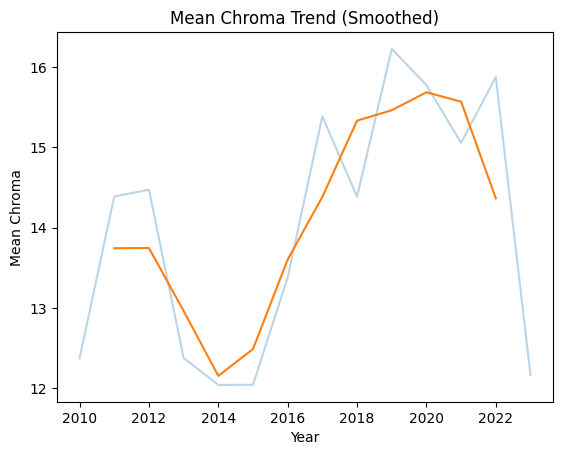

In [8]:
# smooth trend / rolling average to look cool 

yearly["chroma_smooth"] = yearly["mean_chroma"].rolling(3, center=True).mean()
yearly["neutral_smooth"] = yearly["neutral_share"].rolling(3, center=True).mean()

plt.figure()
plt.plot(yearly["year"], yearly["mean_chroma"], alpha=0.3)
plt.plot(yearly["year"], yearly["chroma_smooth"])
plt.xlabel("Year")
plt.ylabel("Mean Chroma")
plt.title("Mean Chroma Trend (Smoothed)")
plt.show()
